# Efeito Chladni: Uma Aplicação das Funções de Bessel

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 04/09/26

$\quad$ As funções de Bessel figuram entre as funções especiais mais conhecidas da matemática e, consequentemente, surgem em inúmeros contextos da Física. O primeiro capítulo deste `Notebook` apresenta a elaboração de um modelo analítico para descrever a vibração de uma membrana circular, cuja solução espacial é expressa justamente em termos dessas funções. Em seguida, o Capítulo 2 explora a evolução temporal dessa solução, permitindo a observação do comportamento vibratório da membrana. Com base nesse resultado, o Capítulo 3 simula a física por trás do Efeito Chladni, utilizando dinâmica de partículas para criar figuras que representam visualmente os padrões sonoros. O Capítulo 4 é dedicado à simulação simultânea da vibração tridimensional e da formação da Figura de Chladni, aplicando o modelo a modos de oscilação de ordem superior. Por fim, o trabalho é encerrado com uma síntese dos resultados obtidos.

A estrutura final do `Notebook` está organizada da seguinte forma:

1. Introdução Teórica;
2. Simulando a Vibração da Membrana; 
3. Figuras de Chladni;
4. Visualização Simultânea;
5. Conclusão.

## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator

## Informações sobre as bibliotecas

In [2]:
%load_ext version_information
%version_information Matplotlib, Numpy

Software versions
Python 3.12.7 64bit [MSC v.1929 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26200 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Sun Aug 30 21:26:23 2026 Hora oficial do Brasil

## 1. Introdução Teórica

$\quad$ A descrição quantitativa da dinâmica de uma membrana circular ideal fundamenta-se na equação de onda bidimensional expressa em coordenadas polares $(r, \theta)$:
$$
\nabla^2 \phi (r, \theta, t) - \frac{1}{c^2}\frac{\partial^2 \phi(r,\theta,t)}{\partial t^2} = 0,
\tag{1.1}
$$
em que $\phi(r, \theta, t)$ representa o deslocamento transversal da membrana em relação à sua posição de equilíbrio no instante $t$, e $c$ denota a velocidade de propagação da onda no meio.


$\quad$ Se pensarmos no comportamento de uma membrana circular enquanto elemento estrutural de um tambor, por exemplo, percebemos que as bordas ficam fixas indefinidamente. Assim, fisicamente, impõe-se a condição de contorno de Dirichlet homogênea na borda circular de raio $a$:
$$
\phi(a, \theta, t) = 0, \quad \forall \theta \in [0, 2\pi], \, t \ge 0.
$$
O objetivo analítico consiste em determinar a família de soluções $\phi(r, \theta, t)$ que satisfaz simultaneamente a equação de onda (Eq. 1.1) e essa restrição física espacial.

Para resolver a Eq. (1.1), empregamos o método de separação de variáveis, postulando que a função de onda pode ser fatorada em componentes independentes para a posição radial $r$, o ângulo polar $\theta$ e o tempo $t$:
$$
\phi (r,\theta,t) = f(r)g(\theta)T(t). \tag{1.2}
$$

Substituindo o produto fatorado na equação de onda expressa em coordenadas polares e dividindo por $f(r)g(\theta)T(t)$, obtemos um sistema de equações diferenciais ordinárias (EDO) desacopladas:

$$
\frac{d^2 T(t)}{dt^2} = -k^2c^2T(t),
\tag{1.3a}
$$
$$
\frac{d^2g(\theta)}{d\theta^2} = -\mu^2g(\theta),
\tag{1.3b}
$$
$$
r^2\frac{d^2f(r)}{dr^2} + r\frac{d f(r)}{dr} + (k^2r^2-\mu^2)f(r) = 0,
\tag{1.3c}
$$
onde $k^2$ e $\mu^2$ surgem como constantes de separação reais e estritamente positivas.

A Eq. (1.3a) é a EDO do oscilador harmônico simples com frequência angular $\omega = ck$, cuja solução geral temporal é dada por:

$$
T(t) = \alpha \cos{(ckt)} + \beta \sin{(ckt)}. \tag{1.4}
$$

$\quad$ De forma análoga, a solução para a componente angular na Eq. (1.3b) assume a forma:
$$
g(\theta) = A\cos{(\mu \theta)} + B\sin{(\mu \theta)}. \tag{1.5}
$$
Devido à unicidade do espaço físico, a função $g(\theta)$ deve ser $2\pi$-periódica, o que impõe rigorosamente a restrição $\mu \in \mathbb{Z}_{\ge 0}$.

$\quad$ A equação diferencial radial (Eq. 1.3c) é formalmente conhecida como a Equação Diferencial de Bessel. Efetuando a mudança de variável adimensional $x = kr$, sua solução geral para ordem inteira $\mu$ é expressa pela combinação linear:
$$
f(r) = CJ_\mu (kr) + D Y_\mu (kr).
\tag{1.6}
$$
em que $J_\mu$ representa a Função de Bessel de primeira espécie de ordem $\mu$, e $Y_\mu$ é a Função de Bessel de segunda espécie (ou Função de Neumann).



$\quad$ Todavia, analisando o comportamento assintótico no centro da membrana, constata-se que $Y_\mu (kr) \to -\infty$ conforme $kr \to 0$. Como a membrana não pode apresentar uma deflexão infinita na origem $r = 0$, essa divergência é fisicamente inaceitável. Para preservar a finitude da solução, anula-se a constante $D = 0$, restando apenas a componente regular:
$$
f(r) = C J_\mu(kr).
\tag{1.7}
$$

$\quad$ Impondo agora a condição de contorno no raio exterior $r = a$, obtemos:
$$
\phi (r = a, \theta, t) = 0 \implies f(a)g(\theta)T(t) = 0 \implies f(a) = 0 \implies J_{\mu}(ka) = 0.
\tag{1.8}
$$

$\quad$ Como a Função de Bessel $J_\mu(x)$ possui natureza oscilatória amortecida, ela cruza o eixo horizontal infinitas vezes. Assim, para que $J_\mu(ka) = 0$, o argumento $ka$ deve coincidir com uma das raízes discretas da função. Denotando por $z_{\mu \nu}$ a $\nu$-ésima raiz positiva de $J_\mu(x)$, temos:
$$
x_{\mu \nu} = z_{\mu \nu},  \tag{1.9}
$$
o que quantiza o número de onda $k$ para cada par de modos $(\mu, \nu)$:
$$
ka = z_{\mu \nu} \implies k_{\mu \nu} = \frac{z_{\mu \nu}}{a}. \tag{1.10}
$$
Desta forma, a solução radial quantizada escreve-se como:
$$
f(r) = CJ_{\mu}\left(\frac{z_{\mu \nu}}{a}r\right). \tag{1.11}
$$

$\quad$ Combinando as três componentes, a solução geral para um modo normal específico $(\mu, \nu)$ assume a forma:
$$
\phi_{\mu \nu}(r, \theta, t) = CJ_\mu\left(\frac{z_{\mu \nu} r}{a}\right)(A_{\mu \nu}\cos{(\mu \theta)} + B_{\mu \nu}\sin{(\mu \theta)}) \left[ \alpha _{\mu \nu}\cos{\left(c\frac{z_{\mu \nu}}{a}t\right)} + \beta_{\mu \nu} \sin{\left(c\frac{z_{\mu \nu}}{a}t\right)}\right].
\tag{1.12}
$$

$\quad$ Mediante a aplicação da identidade trigonométrica $\alpha \cos{x} + \beta \sin{x} = \sqrt{\alpha^2 + \beta^2}\cos{(x - x_0)}$, e efetuando uma rotação do sistema de coordenadas para definir as fases nulas sem perda de generalidade, simplificamos a solução para:
$$
\phi_{\mu \nu}(r, \theta, t) = A' J_\mu\left(\frac{z_{\mu \nu} r}{a}\right) \cos{(\mu \theta)} \cos{\left(c\frac{z_{\mu \nu}}{a}t\right)}, \tag{1.13}
$$
em que $A'$ absorve o produto das constantes de amplitude, sob as restrições $\mu \in \mathbb{Z}_{\ge 0}$ e $\nu \in \mathbb{N}^*$.

$\quad$ Visto que as constantes globais afetam apenas a amplitude de pico da oscilação, podemos normalizar a constante efetiva $A' = 1$ sem alterar a topologia física ou os nós da oscilação. Assim, a expressão final para o modo normal de vibração $(\mu, \nu)$ assume a forma normalizada:
$$
\phi_{\mu \nu}(r, \theta, t) = J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}.
\tag{1.14}
$$

## 2. Simulação a vibração da membrana

$\quad$ Para a devida simulação, primeiro se faz necessário considerar uma discretização da nossa membrana. Isso é feito da maneira usual: geramos $N$ valores igualmente espaçados no intervalo $[0,a]$ para o raio $r$ e no intervalo $[0,2\pi]$ para o ângulo polar $\theta$. Retomando a Eq. (1.14), é possível perceber que, uma vez que decidamos qual modo iremos simular, isto é, escolhendo efetivamente valores para $\mu$ e $\nu$, toda a parte espacial $J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}$ estará devidamente determinada. Assim, para realizarmos a evolução temporal, basta multiplicá-la pelo fator $\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}$, iterando desde $t = 0$ até um instante $t = t_f$ com um determinado número de passos. Feitas essas considerações, já podemos definir as variáveis para a nossa simulação, escolhendo inicialmente os modos $\mu = 2$ e $\nu = 1$.

In [3]:
mu = 2          # Modo angular (número de diâmetros nodais).
nu = 1          # Modo radial (número de círculos nodais).
a = 1.0         # Raio da membrana.
c = 1.0         # Velocidade da onda.

# Obter a nu-ésima raiz de Bessel da ordem mu.
# sp.jn_zeros retorna as primeiras 'nu' raízes. Pegaremos apenas a última ([nu-1]).
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

# Criação da malha polar (com N = 80) e conversão para cartesiana (pois fica mais fácil para plotar).
r = np.linspace(0, a, 80)
theta = np.linspace(0, 2 * np.pi, 80)
R, Theta = np.meshgrid(r, theta)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Parte espacial fixa da equação
spatial_part = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
z_max = np.max(np.abs(spatial_part)) # Será usado para fixar os limites do eixo Z.

$\quad$ Definida essa malha circular correspondente ao plano de repouso da membrana (plano $xy$), podemos considerar que a coordenada vertical $z$ do nosso espaço tridimensional representará simplesmente o valor da função de onda $\phi_{\mu \nu}$ naquele ponto. Em outras palavras, o deslocamento transversal da membrana ditará a altura do gráfico para cada par $(x,y)$. Para iniciar nossa visualização, fixamos o tempo em $t = 0$ e calculamos a matriz de elevação $Z$. A partir disso, utilizamos as ferramentas de projeção 3D para renderizar a superfície da membrana, configurando limites fixos para os eixos, garantindo que o gráfico não mude de escala abruptamente quando formos, no passo seguinte, animar a evolução temporal.

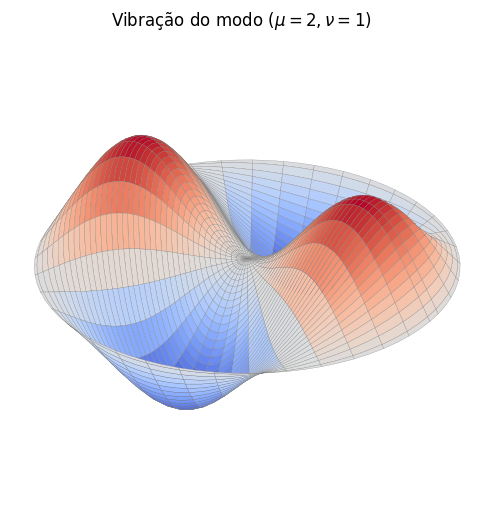

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

t = 0
Z = spatial_part * np.cos(z_munu * c * t / a)

surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

ax.set_xlim(-0.7 * a, 0.7 * a)
ax.set_ylim(-0.7* a, 0.7 * a)
ax.set_zlim(-1.1 * z_max, 1.1 * z_max)

ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$")
ax.set_axis_off()

$\quad$ O plot anterior mostra simplesmente o estado da membrana no instante $t = 0$. No entanto, para visualizarmos a dinâmica do sistema, podemos definir uma função iterativa que atualiza o valor do tempo $t$ em pequenos incrementos $\Delta t$. Com isso, poderemos animar a evolução da onda e gerar um GIF que ilustra perfeitamente o comportamento físico desse modo de vibração.

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
plt.close() # Fecha a figura estática, que não queremos que seja plotada ainda.

def update(frame):
    ax.clear()
    t = frame * 0.05    
    
    # Adiciona a evolução temporal cos(z_munu * c * t / a).
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

    ax.set_xlim(-0.7 * a, 0.7 * a)
    ax.set_ylim(-0.7 * a, 0.7 * a)
    ax.set_zlim(-1.1 * z_max, 1.1 * z_max)
    
    ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$ - Evolução temporal: ${frame/100.0:.0f}$%")
    ax.set_axis_off()  # Oculta eixos para destacar a superfície.
    
    return surf,

$\quad$ Agora, vamos efetivamente gerar a animação.

In [6]:
frames = 100 # Efetivamente o tempo final.
anim = FuncAnimation(fig, update, frames=frames, interval=40, blit=False)

# Salvando a animação como GIF.
caminho = '../Imagens/Bessel/Membrana_Vibratoria_2_1.gif'
anim.save(caminho, writer="pillow", fps=25)

<p align="center">
  <img src="../Imagens/Bessel/Membrana_Vibratoria_2_1.gif" width="70%" alt="Oscilação da Membrana">
</p>

$\quad$ Ao observarmos o resultado final da animação, fica evidente a rica dinâmica espacial do modo que escolhemos simular. Um dos aspectos mais interessantes dessa visualização é a presença de regiões da membrana que permanecem perfeitamente estáticas durante toda a evolução temporal, isto é, elas não sobem nem descem. Esses locais, onde a amplitude de vibração é sempre nula (isto é, $\phi = 0$ para qualquer instante $t$), formam o que chamamos de linhas e círculos nodais. A geometria e a quantidade dessas regiões de repouso são ditadas exatamente pelos "números quânticos" $\mu$ e $\nu$ que definimos no código. Como veremos a seguir, essa característica dá origem a um belo fenômeno visual da física ondulatória.

## 3. Figuras de Chladni

$\quad$ A experiência de observar uma Figura de Chladni é o mais próximo que temos de poder "ver o som". Esse fenômeno ocorre quando a frequência de uma força externa atuando sobre uma superfície coincide com uma de suas frequências de oscilação natural, um processo conhecido como ressonância. De forma resumida, se espalharmos um número elevado de partículas (como grãos de areia) sobre essa superfície vibrante, elas serão fisicamente "expulsas" das áreas de grande amplitude e acabarão se acumulando justamente nas regiões estáticas que acabamos de discutir: as linhas nodais. Esse efeito pode ser observado em superfícies de diferentes geometrias, desde placas quadradas e circulares até triangulares. Nesta seção, simularemos a formação de um padrão de Chladni na mesma membrana circular que vínhamos utilizando.

<p align="center">
  <img src="../Imagens/Bessel/Chladni.png" width="70%" alt="Imagem da Figura de Chladni">
</p>

**Figura 1: Formação de uma Figura de Chladni numa superfície quadrada.**

$\quad$ Para modelar esse fenômeno computacionalmente, assumiremos que as partículas se movem na direção do gradiente negativo da amplitude de oscilação da membrana. Em termos mais intuitivos, os grãos "deslizam morro abaixo", sentindo uma força que as direciona para as regiões onde a vibração é nula. No entanto, para tornar a simulação fisicamente mais realista, precisamos adicionar um fator estocástico (aleatório) ao nosso modelo. Esse ruído simula a natureza não pontual dos grãos, as colisões entre eles durante a vibração e as pequenas imperfeições da superfície, garantindo que o movimento não seja pura e artificialmente determinístico.

$\quad$ Para iniciar a simulação, definimos novamente as propriedades fundamentais do sistema. Reaproveitaremos os parâmetros espaciais e modais definidos na seção anterior, adicionando agora a quantidade de partículas, a velocidade de migração em direção aos nodos e a intensidade do ruído aleatório.

In [7]:
# Utilizaremos os mesmos parâmetros de antes (mu = 2, nu = 1 e a = 1.0).

N_particles = 8000  # Quantidade de grãos de areia.
step_size = 0.008    # Velocidade de migração (intensidade do movimento rumo aos nodos).
noise_std = 0.005   # Agitação estocástica (ruído para simular colisões e imperfeições).

$\quad$ Com os parâmetros da simulação e o comportamento das partículas já definidos, podemos agora preparar o ambiente no qual essa areia irá se deslocar. Dessa vez vamos construir a grade referente à membrana com uma resolução maior, uma vez que teremos que calcular derivadas numéricas dentro dela.

$\quad$ Dentro dessa grade, calcularemos a função de onda da membrana (baseada nas raízes de Bessel) e elevaremos sua amplitude ao quadrado para definir um "potencial" de vibração ($U$). É neste ponto que o gradiente numérico entra em ação: ele quantifica as taxas de variação espacial da amplitude, transformando nossa superfície escalar estática em um mapa vetorial de inclinações. Como a areia sempre busca as áreas de menor agitação, definimos os vetores de força ($F_x, F_y$) na direção contrária a esse gradiente. Isso garante que a física do modelo "empurre" os grãos em direção aos vales locais (as linhas nodais).

$\quad$ Por fim, precisamos conectar esse ambiente estático às nossas partículas dinâmicas. Como a malha computacional é discreta e os grãos de areia assumirão posições contínuas (coordenadas fracionárias), eles dificilmente cairão em cima de um ponto exato da grade. O uso de interpoladores bidimensionais resolve esse problema. Eles mapeiam os dados limitados aos nós da malha e constroem uma aproximação contínua do campo de forças. Isso permite calcular o vetor exato da força que atua sobre cada partícula em qualquer lugar da membrana, garantindo um movimento fluido e transições suaves na nossa futura simulação.

In [8]:
# Criação de uma grade cartesiana fina para calcular derivadas numéricas.
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X, Y = np.meshgrid(x_grid, y_grid)

R = np.hypot(X, Y)
Theta = np.arctan2(Y, X)
mask = R <= a  # Máscara para manter cálculos dentro do círculo; Impede que ruídos de borda e artefatos numéricos dos cantos da grade quadrada interfiram no cálculo.

# Calcula a raiz de Bessel e o módulo da amplitude (Potencial U).
z_munu = sp.jn_zeros(mu, nu)[nu - 1]
phi = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
phi[~mask] = 0
U = phi**2  # A areia foge dos picos de amplitude.

# Gradiente numérico do potencial.
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y  # Força aponta contra o gradiente (para o zero).

# Interpoladores para calcular a força em qualquer ponto (x,y).
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)

$\quad$ Com o campo de forças pronto e as regras de movimento estabelecidas, o próximo passo é posicionar os grãos de areia antes da "batida" no tambor. Precisamos garantir que as partículas comecem uniformemente espalhadas por toda a superfície da membrana, sem se concentrarem artificialmente no centro. Para obter uma distribuição de probabilidade verdadeiramente uniforme em um disco circular, aplicamos a raiz quadrada sobre os valores aleatórios do raio ($r_{\text{init}}$), equilibrando o elemento de área e evitando distorções geométricas. Em seguida, convertemos essas posições polares de volta para coordenadas cartesianas para facilitar o cálculo do deslocamento vetorial e da interpolação durante a animação.

In [9]:
# Espalha partículas aleatoriamente dentro do círculo
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)

pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)

$\quad$ Antes de iniciarmos o processo iterativo de migração dos grãos, vamos visualizar a configuração inicial das partículas espalhadas sobre a membrana circular. Este passo serve como validação do nosso sorteio espacial e estabelece o estado de repouso ($t = 0$) a partir do qual o padrão estocástico começará a se desenhar.

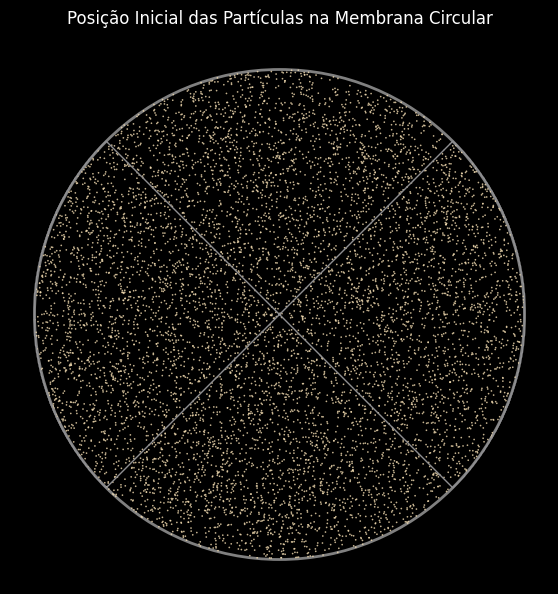

In [10]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')
ax.set_facecolor('black')
ax.set_aspect('equal')
ax.set_xlim(-1.1 * a, 1.1 * a)
ax.set_ylim(-1.1 * a, 1.1 * a)
ax.axis('off')
ax.set_title(f"Posição Inicial das Partículas na Membrana Circular", color='white', pad=15)

# Desenha as linhas nodais teóricas ao fundo.
ax.contour(X, Y, phi, levels=[0], colors="#8F8F92", linewidths=1)

# Borda da membrana.
circulo = plt.Circle((0, 0), a, color='gray', fill=False, linewidth=2)
ax.add_patch(circulo)

# Plot inicial das partículas.
scatter = ax.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

$\quad$ Novamente, podemos definir uma função de atualização para evoluir a configuração do sistema em pequenos incrementos de tempo. Contudo, desta vez, é necessário calcular iterativamente o campo de forças interpolado que atua sobre a posição exata de cada partícula a cada passo temporal, somando o deslocamento determinístico à componente de agitação estocástica.

In [11]:
def update(frame):
    global pos_x, pos_y
    
    ax.set_title(f"Formação da Figura de Chladni - Evolução: {frame/150*100:.0f}%", color='white', pad=15)

    # Prepara coordenadas para o interpolador (y, x).
    pts = np.vstack((pos_y, pos_x)).T
    
    # Interpola a força vetorial no ponto exato de cada partícula.
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)
    
    # Atualiza posição = Força Determinística + Ruído Gaussiano.
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)
    
    # Condição de contorno: remove a areia que escapa do tambor.
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = 999
    pos_y[fora] = 999
    
    # Atualiza as posições no gráfico de espalhamento.
    scatter.set_offsets(np.c_[pos_x, pos_y])
    return scatter,

$\quad$ Com a função de atualização devidamente configurada, podemos gerar a animação, observando a migração progressiva dos grãos de areia até a formação completa da Figura de Chladni.

In [12]:
# Geração da animação.
anim = FuncAnimation(fig, update, frames=150, interval=80, blit=True)

# Salvando a animação como GIF.
caminho = '../Imagens/Bessel/Figura_de_Chladni.gif'
anim.save(caminho, writer="pillow", fps=20)

<p align="center">
  <img src="../Imagens/Bessel/Figura_de_Chladni.gif" width="70%" alt="Formação da Figura de Chladni">
</p>

$\quad$ Ao comparar este resultado com a visualização tridimensional da oscilação da membrana, fica evidente a correspondência física entre a dinâmica vetorial e a geometria do modo: as partículas migram naturalmente das regiões de alta amplitude em direção aos locais onde o deslocamento transversal é mínimo ou nulo. Esse comportamento estocástico confirma que os grãos de areia se acumulam precisamente sobre as linhas e círculos nodais ($\phi = 0$), traduzindo um fenômeno de onda em um padrão visível que caracteriza perfeitamente o modo de vibração $(\mu, \nu)$.

## 4. Visualização Simultânea

$\quad$ Para consolidar nossa análise, integramos ambas as abordagens em uma única visualização comparativa lado a lado: a oscilação tridimensional da membrana à esquerda e a dinâmica de acúmulo das partículas (Figura de Chladni) à direita. Para demonstrar a capacidade de generalização e a robustez do modelo, aplicaremos o algoritmo a um modo de vibração de ordem superior, definindo $\mu = 6$ e $\nu = 6$. Essa configuração resulta em uma imagem nodal consideravelmente mais rica e complexa, caracterizada por um número elevado de diâmetros e círculos nodais entrelaçados.

In [13]:
mu = 6          # Modo angular (número de diâmetros nodais).
nu = 6          # Modo radial (número de círculos nodais).
c = 1.0         # Velocidade da onda.

# Parâmetros das partículas (Chladni).
N_particles = 10000  # Quantidade de partículas.
step_size = 0.005   # Passo menor para evitar overshooting nos nós estreitos.
noise_std = 0.003

# Raiz de Bessel z_{mu, nu}.
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

$\quad$ Da mesma maneira como fizemos anteriormente, iniciamos construindo a malha de discretização polar para o espaço 3D, convertendo-a para coordenadas cartesianas $(X_{\text{3D}}, Y_{\text{3D}})$. Em seguida, calculamos a parte espacial fixa da equação de onda, $J_\mu(z_{\mu\nu} r / a) \cos(\mu \theta)$, agora adaptada aos novos modos de ordem superior ($\mu = 6, \nu = 6$). A partir dessa superfície escalar, determinamos o valor de $z_{\text{max}}$, que garantirá a estabilidade da escala vertical ao longo de toda a renderização temporal.

In [14]:
# Discretização da malha polar para o plot 3D.
r_3d = np.linspace(0, a, 100)
theta_3d = np.linspace(0, 2 * np.pi, 100)
R_3d, Theta_3d = np.meshgrid(r_3d, theta_3d)

# Conversão para coordenadas cartesianas.
X_3d = R_3d * np.cos(Theta_3d)
Y_3d = R_3d * np.sin(Theta_3d)

# Parte espacial fixa da equação de onda.
spatial_part = sp.jn(mu, z_munu * R_3d / a) * np.cos(mu * Theta_3d)
z_max = np.max(np.abs(spatial_part))

$\quad$ Analogamente ao procedimento realizado para o modo anterior, construímos a grade cartesiana fina necessária para determinar o potencial escalar $U = \phi^2$ associado ao modo $(\mu = 6, \nu = 6)$. A partir dessa distribuição de amplitudes, calculamos o campo vetorial de forças $(F_x, F_y) = -\nabla U$ e configuramos os interpoladores espaciais bidimensionais. Por fim, geramos a distribuição inicial uniforme das partículas sobre a superfície do disco, deixando o sistema bidimensional pronto para evoluir em sincronia com a membrana tridimensional.

In [15]:
# Discretização em grade cartesiana fina para o cálculo do campo vetorial 2D.
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X_2d, Y_2d = np.meshgrid(x_grid, y_grid)

R_2d = np.hypot(X_2d, Y_2d)
Theta_2d = np.arctan2(Y_2d, X_2d)
mask = R_2d <= a  # Máscara circular de raio 'a'.

phi = sp.jn(mu, z_munu * R_2d / a) * np.cos(mu * Theta_2d)
phi[~mask] = 0
U = phi**2  # Potencial proporcional à energia de aceleração (U = phi^2).

# Cálculo do gradiente numérico e determinação do campo de forças (-grad U).
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y

# Construção dos interpoladores continuos de força.
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)

# Sorteio uniforme da posição inicial das partículas dentro do disco.
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)
pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)

$\quad$ Para inicializar a visualização simultânea no instante $t = 0$, construímos uma figura composta com dois subplots dispostos lado a lado sobre um fundo escuro contrastante. O painel da esquerda é destinado à renderização da superfície tridimensional da membrana oscilante, enquanto o painel da direita apresenta o plano bidimensional com a distribuição inicial das partículas de areia. Essa configuração estática serve como verificação fundamental da escala dos eixos e do alinhamento dos elementos visuais antes de iniciarmos a evolução dinâmica temporal.

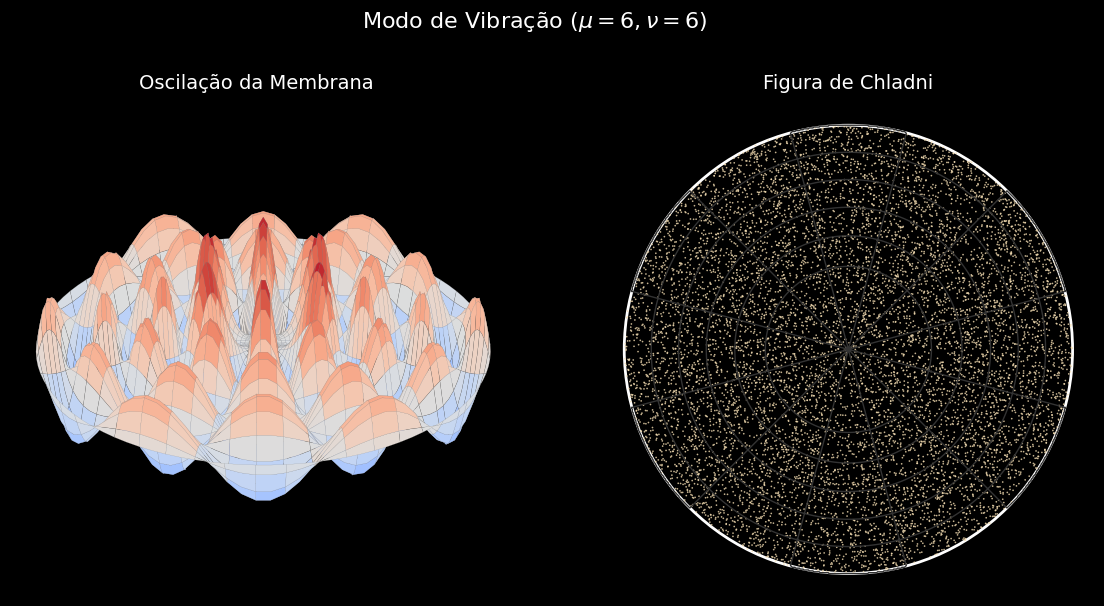

In [16]:
fig = plt.figure(figsize=(14, 7), facecolor='black')

# Subplot 1: Membrana 3D (Esquerda).
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('black')
ax1.set_axis_off()
ax1.set_xlim(-0.7 * a, 0.7 * a) 
ax1.set_ylim(-0.7 * a, 0.7 * a)
ax1.set_zlim(-1.1 * z_max, 1.1 * z_max)
ax1.set_title('Oscilação da Membrana', color='white', fontsize=14, pad=10)

# Subplot 2: Chladni 2D (Direita).
ax2 = fig.add_subplot(122)
ax2.set_facecolor('black')
ax2.set_aspect('equal')
ax2.set_xlim(-1.1 * a, 1.1 * a)
ax2.set_ylim(-1.1 * a, 1.1 * a)
ax2.axis('off')
ax2.set_title('Figura de Chladni', color='white', fontsize=14, pad=10)

# Elementos estáticos do painel 2D.
ax2.contour(X_2d, Y_2d, phi, levels=[0], colors='#333333', linewidths=1)
circulo = plt.Circle((0, 0), a, color='white', fill=False, linewidth=2)
ax2.add_patch(circulo)
scatter = ax2.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

fig.suptitle(f"Modo de Vibração $(\\mu={mu}, \\nu={nu})$", color='white', fontsize=16)

# Estado da membrana em t = 0.
t = 0
Z = spatial_part * np.cos(z_munu * c * t / a)

surf = ax1.plot_surface(
    X_3d, Y_3d, Z, 
    cmap='coolwarm', 
    vmin=-z_max, vmax=z_max, 
    linewidth=0.1, edgecolor='gray', antialiased=True
)

$\quad$ Para realizar a evolução temporal sincronizada de ambos os sistemas, definimos uma função de atualização iterativa que processa cada quadro da animação. No painel tridimensional, a topologia da superfície é recalculada a cada passo de tempo $t$ e re-renderizada sobre o eixo correspondente, atualizando a deflexão transversal $Z(x, y, t)$. Simultaneamente, no painel bidimensional, o algoritmo aplica o operador de interpolação sobre o conjunto discreto de partículas, adiciona o deslocamento estocástico e impõe a condição de contorno radial.

In [17]:
def update(frame):
    global pos_x, pos_y
    t = frame * 0.02
    
    # Atualiza Lado Esquerdo (3D).
    ax1.clear()
    ax1.set_facecolor('black')
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax1.plot_surface(
        X_3d, Y_3d, Z, 
        cmap='coolwarm', 
        vmin=-z_max, vmax=z_max, 
        linewidth=0.1, edgecolor='gray', antialiased=True
    )
    
    ax1.set_xlim(-1.1 * a, 1.1 * a)
    ax1.set_ylim(-1.1 * a, 1.1 * a)
    ax1.set_zlim(-1.2 * z_max, 1.2 * z_max)
    ax1.set_axis_off()
    ax1.set_title(f"Oscilação da Membrana - Evolução: $t = {frame/50*100:.0f}$ s", color='white', pad=10)

    # Atualiza Lado Direito (2D Areia).
    pts = np.vstack((pos_y, pos_x)).T
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)

    # Movimento: Força Determinística + Ruído.
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)

    # Condição de contorno: remove a areia que escapa do tambor.
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = 999
    pos_y[fora] = 999

    scatter.set_offsets(np.c_[pos_x, pos_y])
    ax2.set_title("Formação da Figura de Chladni", color='white', pad=10)
    
    return surf, scatter

$\quad$ Com a função de atualização devidamente definida para ambos os painéis, efetuamos a renderização e compilação da animação. O resultado final é exportado em formato GIF, registrando simultaneamente a oscilação tridimensional da membrana e a migração estocástica dos grãos de areia até a consolidação completa da Figura de Chladni para o modo de ordem superior $(\mu = 6, \nu = 6)$.

In [18]:
# Geração da animação sincronizada (blit=False devido à reconstrução do eixo 3D a cada frame)
ani = FuncAnimation(fig, update, frames=50, interval=50, blit=False)

# Salvamento do arquivo em formato GIF
caminho = '../Imagens/Bessel/Chladni_Oscilacao_Combinada.gif'
ani.save(caminho, writer='pillow', fps=10)

<p align="center">
  <img src="../Imagens/Bessel/Chladni_Oscilacao_Combinada.gif" width="70%" alt="Evolução Conjunta">
</p>

## 5. Conclusão

$\quad$ Este `Notebook` apresentou uma jornada completa pelo estudo das membranas circulares vibrantes, articulando desde a fundamentação teórica baseada nas equações diferenciais parciais e funções de Bessel $J_\mu$, passando pela modelagem tridimensional da oscilação da membrana em coordenadas polares, até a formulação física das Figuras de Chladni via dinâmica estocástica sob o potencial $U = \phi^2$. A visualização combinada lado a lado não apenas comprovou visual e numericamente a convergência dos grãos de areia para as linhas nodais de amplitude nula, como também atestou a robustez do algoritmo frente a modos de vibração complexos e de ordem elevada como $(\mu = 6, \nu = 6)$.

## Referências


**[1]** https://www.acs.psu.edu/drussell/Demos/MembraneCircle/Circle.html 

**[2]** https://pt.wikipedia.org/wiki/Figura_de_Chladni

**[3]** https://www.comsol.com/blogs/how-do-chladni-plates-make-it-possible-to-visualize-sound

**[4]** O. Devauchelle, P. Popović, P. Szymczak, A. Abramian, A. Lazarus. Thermodynamics of bouncing grains.
Physical Review E , 2026, 114 (2), pp.025420. ⟨10.1103/zlsc-w7m4⟩. ⟨hal-05725479⟩

**[5]** 